In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
name = 'csv/test8_100hz-1CH-struct.csv'

In [7]:

# Lee el CSV con separador ';'
df = pd.read_csv(name, sep=';')

# Verifica cómo quedó
print(df.head(41))


              Time  UART CH1
1,107076205  Start       NaN
1,107084885   0x65       NaN
1,107154325   Stop       NaN
1,107163195  Start       NaN
1,107171875   0xad       NaN
1,107241315   Stop       NaN
1,107250160  Start       NaN
1,107258840   0x66       NaN
1,107328280   Stop       NaN
1,107337045  Start       NaN
1,107345725   0xad       NaN
1,107415165   Stop       NaN
1,107424025  Start       NaN
1,107432705   0x69       NaN
1,107502145   Stop       NaN
1,107510820  Start       NaN
1,107519500   0x52       NaN
1,107588940   Stop       NaN
1,107597830  Start       NaN
1,107606510   0x6b       NaN
1,107675950   Stop       NaN
1,107684895  Start       NaN
1,107693575   0xee       NaN
1,107763015   Stop       NaN
1,107771845  Start       NaN
1,107780525   0x70       NaN
1,107849965   Stop       NaN
1,107858655  Start       NaN
1,107867335   0x26       NaN
1,107936775   Stop       NaN
1,107945445  Start       NaN
1,107954125   0x74       NaN
1,108023565   Stop       NaN
1,108032390  S

In [8]:
df = df[35:]
print(df.head(20))

              Time  UART CH1
1,108110510   Stop       NaN
1,108119370  Start       NaN
1,108128050   0x78       NaN
1,108197490   Stop       NaN
1,108206345  Start       NaN
1,108215025   0xd2       NaN
1,108284465   Stop       NaN
1,108293275  Start       NaN
1,108301955   0x7a       NaN
1,108371395   Stop       NaN
1,108380130  Start       NaN
1,108388810   0xfa       NaN
1,108458250   Stop       NaN
1,108467125  Start       NaN
1,108475805   0x7f       NaN
1,108545245   Stop       NaN
1,108554035  Start       NaN
1,108562715   0x9f       NaN
1,108632155   Stop       NaN
1,108640935  Start       NaN


In [9]:

df = df.drop('UART CH1', axis = 1)
df["tiempos"]  = df.index
# Verifica cómo quedó
print(df.head(20))

              Time      tiempos
1,108110510   Stop  1,108110510
1,108119370  Start  1,108119370
1,108128050   0x78  1,108128050
1,108197490   Stop  1,108197490
1,108206345  Start  1,108206345
1,108215025   0xd2  1,108215025
1,108284465   Stop  1,108284465
1,108293275  Start  1,108293275
1,108301955   0x7a  1,108301955
1,108371395   Stop  1,108371395
1,108380130  Start  1,108380130
1,108388810   0xfa  1,108388810
1,108458250   Stop  1,108458250
1,108467125  Start  1,108467125
1,108475805   0x7f  1,108475805
1,108545245   Stop  1,108545245
1,108554035  Start  1,108554035
1,108562715   0x9f  1,108562715
1,108632155   Stop  1,108632155
1,108640935  Start  1,108640935


In [10]:
df = df[df['Time'] != 'Start']
df = df[df['Time'] != 'Stop']
print(df.head())

             Time      tiempos
1,108128050  0x78  1,108128050
1,108215025  0xd2  1,108215025
1,108301955  0x7a  1,108301955
1,108388810  0xfa  1,108388810
1,108475805  0x7f  1,108475805


In [11]:
df['Time'] = df['Time'].apply(lambda x: int(x, 16))

In [12]:
# Verifica cómo quedó
print(df.head())


             Time      tiempos
1,108128050   120  1,108128050
1,108215025   210  1,108215025
1,108301955   122  1,108301955
1,108388810   250  1,108388810
1,108475805   127  1,108475805


In [13]:
df = df.reset_index(drop=True)
print(df.head())


   Time      tiempos
0   120  1,108128050
1   210  1,108215025
2   122  1,108301955
3   250  1,108388810
4   127  1,108475805


In [14]:

f = 1/(float(df['tiempos'][2].replace(',', '.'))-float(df['tiempos'][0].replace(',', '.')))

print("frecuencia de muestreo: ", f)

frecuencia de muestreo:  5750.265949799195


In [15]:
arr = df['Time'].values
arr

array([120, 210, 122, ..., 153,  96, 149], shape=(44772,))

In [19]:

new_arr = []
for i in range(0, len(arr) - 1, 2):
    new_arr.append(arr[i]*256 + arr[i+1])

new_arr = np.array(new_arr)
new_arr

array([30930, 31482, 32671, ..., 26187, 25241, 24725], shape=(22386,))

In [20]:
t = np.arange(len(df)) / f  # eje tiempo en segundos

In [21]:

fig = go.Figure()

fig.add_trace(go.Scatter(
    x = t,
    y=new_arr,
    mode='lines+markers',
    name='Valores concatenados'
))

fig.update_layout(
    title='Gráfico interactivo con zoom',
    xaxis_title='Tiempo',
    yaxis_title='Valor',
    hovermode='x unified'
)

fig.show()


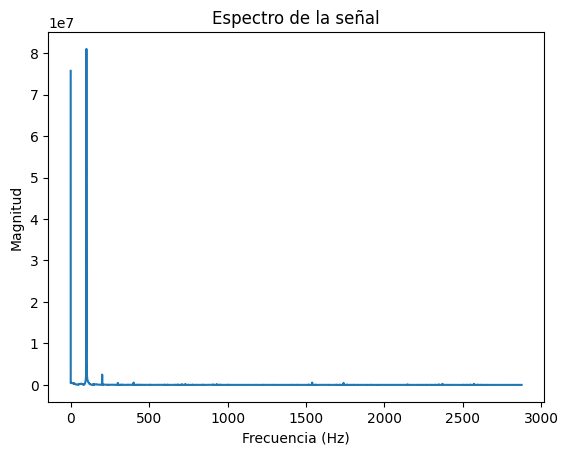

In [22]:
ceros = np.zeros(100)  
# FFT
X = np.fft.fft(np.concatenate((ceros,(new_arr-32768))))

# Número de muestras
N = len(X)

# Frecuencias asociadas (eje x)
freqs = np.fft.fftfreq(N, 1/f)

# Magnitud (módulo)
magnitud = np.abs(X)

# Para mostrar solo la mitad positiva (frecuencias positivas)
idxs = freqs >= 0

plt.plot(freqs[idxs], magnitud[idxs])
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.title("Espectro de la señal")
plt.show()

In [23]:

fig = go.Figure()

fig.add_trace(go.Scatter(
    x = freqs[idxs],
    y=magnitud[idxs],
    mode='lines+markers',
    name='Valores concatenados'
))

fig.update_layout(
    title='FFT',
    xaxis_title='Frecuencia',
    yaxis_title='Magnitud',
    hovermode='x unified'
)

fig.show()